In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset 
# Make sure your .xlsx file is in the same folder as this notebook!
df = pd.read_excel('Delinquency_prediction_dataset.xlsx')

# 2. Quick Look
print("--- DATASET OVERVIEW ---")
display(df.head()) # Jupyter mein 'display' se table sundar dikhti hai

# 3. Missing Values Check
print("\n--- MISSING VALUES ---")
missing = df.isnull().sum()
display(missing[missing > 0]) # Income column par dhyan dein

# 4. Inconsistency Check (Categorical)
print("\n--- EMPLOYMENT STATUS TYPOS ---")
# Isse humein 'EMP' vs 'employed' wale errors milenge
display(df['Employment_Status'].value_counts(dropna=False))

# 5. Risk Correlation (The most important part for your report)
print("\n--- TOP RISK FACTORS ---")
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Delinquent_Account'].sort_values(ascending=False)
display(correlations)

--- DATASET OVERVIEW ---


,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late



--- MISSING VALUES ---


Income          39
Credit_Score     2
Loan_Balance    29
dtype: int64


--- EMPLOYMENT STATUS TYPOS ---


Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64


--- TOP RISK FACTORS ---


Delinquent_Account      1.000000
Income                  0.045409
Credit_Score            0.034833
Debt_to_Income_Ratio    0.034386
Credit_Utilization      0.034224
Age                     0.022508
Loan_Balance           -0.004320
Missed_Payments        -0.026478
Account_Tenure         -0.039829
Name: Delinquent_Account, dtype: float64

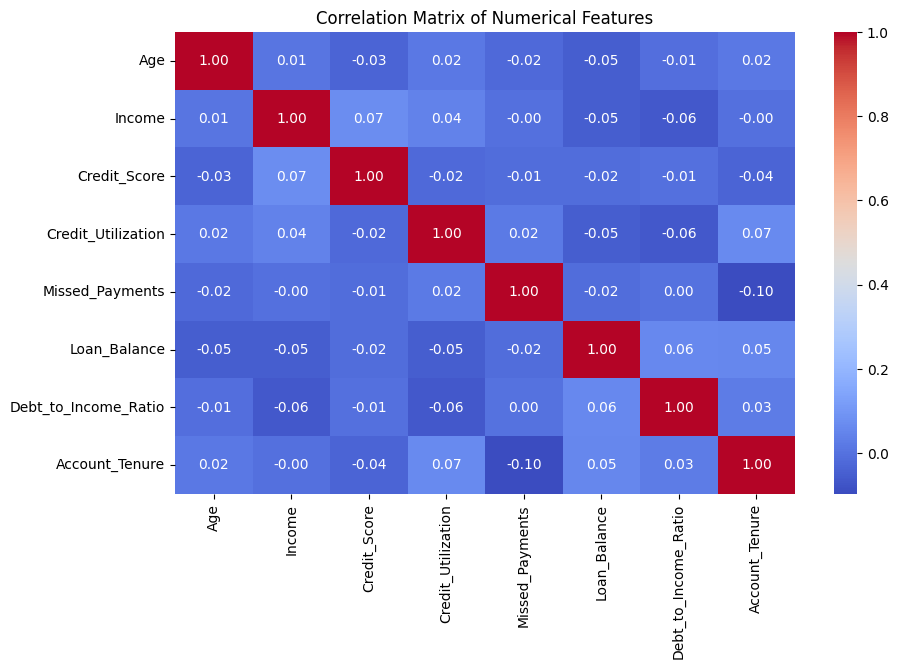

In [2]:
# Run this in a new Jupyter cell to get the heatmap
plt.figure(figsize=(10, 6))
# We drop the Target variable itself so the chart focuses on the features
sns.heatmap(numeric_df.drop('Delinquent_Account', axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()